In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score

# 중요도 판별
import eli5 
from eli5.sklearn import PermutationImportance 
from xgboost import XGBClassifier
from xgboost import plot_importance

# PyTorch 관련 import
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [2]:
train_val = pd.read_csv("train.csv")
display(train_val.head())

,Mass_Pilot,Width,Aspect,Inch,Plant,Proc_Param1,Proc_Param2,Proc_Param3,Proc_Param4,Proc_Param5,...,p247,p248,p249,p250,p251,p252,p253,p254,p255,Class
0,False,245,40,19,Plant_6,465.00,631.85,1460.8,1985,2059,...,1.475031,1.473817,1.472950,1.474981,1.477011,1.479157,1.483289,1.487421,1.491552,Good
1,False,275,40,21,Plant_2,516.01,701.87,1621.1,2205,2291,...,1.320114,1.326607,1.333636,1.340665,1.347694,1.352602,1.355859,1.359115,1.362371,Good
2,False,225,45,17,Plant_7,416.99,583.14,1310.0,1832,1918,...,1.344303,1.346259,1.348215,1.350183,1.352166,1.354149,1.356112,1.358066,1.360021,Good
3,True,275,30,20,Plant_7,490.01,623.89,1539.4,1960,2040,...,1.389538,1.389953,1.393673,1.397393,1.401113,1.405803,1.411120,1.416437,1.421754,Good
4,True,265,45,21,Plant_2,516.01,714.61,1621.1,2245,2336,...,1.435297,1.431648,1.428000,1.424352,1.420704,1.417607,1.415256,1.412904,1.410553,Good


In [3]:
# 2. Train/Val 분리 

# 타겟 변수 생성 (NG=1, Good=0)
train_Y_series = train_val['Class'].apply(lambda x: 1 if x == 'NG' else 0)

all_indices = train_Y_series.index
all_labels = train_Y_series.values

ng_indices = all_indices[all_labels == 1]
good_indices = all_indices[all_labels == 0]

val_ng_count = min(15, len(ng_indices))
val_good_count = min(45, len(good_indices))

np.random.seed(42)
val_ng_indices = np.random.choice(ng_indices, val_ng_count, replace=False)
val_good_indices = np.random.choice(good_indices, val_good_count, replace=False)
val_indices = np.concatenate([val_ng_indices, val_good_indices])
train_indices = np.setdiff1d(all_indices, val_indices)

# 데이터 분할
train_df_split = train_val.iloc[train_indices]
val_df_split = train_val.iloc[val_indices]
y_train_labels = train_Y_series.iloc[train_indices]
y_val_labels = train_Y_series.iloc[val_indices]

print(f"  Train set: {len(train_indices)}개, Validation set: {len(val_indices)}개")
print(f"  Train - NG: {(y_train_labels==1).sum()}개, Good: {(y_train_labels==0).sum()}개")
print(f"  Val - NG: {(y_val_labels==1).sum()}개, Good: {(y_val_labels==0).sum()}개")

  Train set: 660개, Validation set: 60개
  Train - NG: 92개, Good: 568개
  Val - NG: 15개, Good: 45개


In [4]:
print(train_df_split.head())
print(val_df_split.head())
print(y_train_labels.head())
print(y_val_labels.head())

   Mass_Pilot  Width  Aspect  Inch    Plant  Proc_Param1  Proc_Param2  \
0       False    245      40    19  Plant_6       465.00       631.85   
1       False    275      40    21  Plant_2       516.01       701.87   
2       False    225      45    17  Plant_7       416.99       583.14   
3        True    275      30    20  Plant_7       490.01       623.89   
4        True    265      45    21  Plant_2       516.01       714.61   

   Proc_Param3  Proc_Param4  Proc_Param5  ...      p247      p248      p249  \
0       1460.8         1985         2059  ...  1.475031  1.473817  1.472950   
1       1621.1         2205         2291  ...  1.320114  1.326607  1.333636   
2       1310.0         1832         1918  ...  1.344303  1.346259  1.348215   
3       1539.4         1960         2040  ...  1.389538  1.389953  1.393673   
4       1621.1         2245         2336  ...  1.435297  1.431648  1.428000   

       p250      p251      p252      p253      p254      p255  Class  
0  1.474981  1.

In [5]:
train_x = train_df_split.drop(columns=['Class']).iloc[:,:-256*3]
train_y = y_train_labels

val_x = val_df_split.drop(columns=['Class']).iloc[:,:-256*3]
val_y = y_val_labels

In [6]:
cat_list = train_x.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list = sorted(list(set(train_x.columns) - set(cat_list)))

OE = OneHotEncoder(min_frequency=0.01,handle_unknown='infrequent_if_exist',sparse_output=False)
OE.fit(train_x[cat_list])

def preprocess(dataset, category_list, numeric_list):
    Xc = OE.transform(dataset[category_list])
    Xn = np.array(dataset[numeric_list])
    return np.concatenate([Xc, Xn], axis=1)

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_x, cat_list, num_list), train_y)

pred = model.predict_proba(preprocess(val_x, cat_list, num_list))[:,1]

In [11]:
def _calculate_competition_score(y_true, y_prob):
        """경진대회 점수 계산"""
        # ROC-AUC
        roc_auc = roc_auc_score(y_true, y_prob)
        
        # Net Profit
        k = 20
        df_eval = pd.DataFrame({'prob': y_prob, 'true_label': y_true})
        selected_products_df = df_eval.nsmallest(k, 'prob')
        
        correct_good_count = (selected_products_df['true_label'] == 0).sum()
        incorrect_ng_count = (selected_products_df['true_label'] == 1).sum()
        total_net_profit = (100 * correct_good_count) - (500 * incorrect_ng_count)
        
        # Final Score
        auc_comp = max(roc_auc - 0.5, 0) / 0.5
        profit_comp = max(total_net_profit, 0) / 2000
        total_score = np.sqrt(auc_comp * profit_comp)
        
        return total_score, roc_auc, total_net_profit, k



In [12]:
total_score, roc_auc, total_net_profit, k = _calculate_competition_score(y_val_labels, pred)
print(f'AUC: {roc_auc:.4f}, Net Profit: {total_net_profit}, Score: {total_score:.4f}')

AUC: 0.8622, Net Profit: 1400, Score: 0.7121


원본 feature 개수: 30
전처리된 feature 개수: 41
모델이 기대하는 feature 개수: 41

📊 Permutation Importance 상위 41개 Feature


,feature,weight,std
0,G4,1.540741e-02,0.005668
1,Y1,9.629630e-03,0.017293
2,Plant_Plant_7,9.185185e-03,0.004949
3,X5,8.592593e-03,0.011605
4,Proc_Param6_P6_1,7.555556e-03,0.003139
5,Proc_Param9,6.074074e-03,0.006266
6,Inch,4.444444e-03,0.003378
7,Proc_Param1,3.259259e-03,0.003365
8,Proc_Param4,2.666667e-03,0.005208
9,Width,2.370370e-03,0.004405


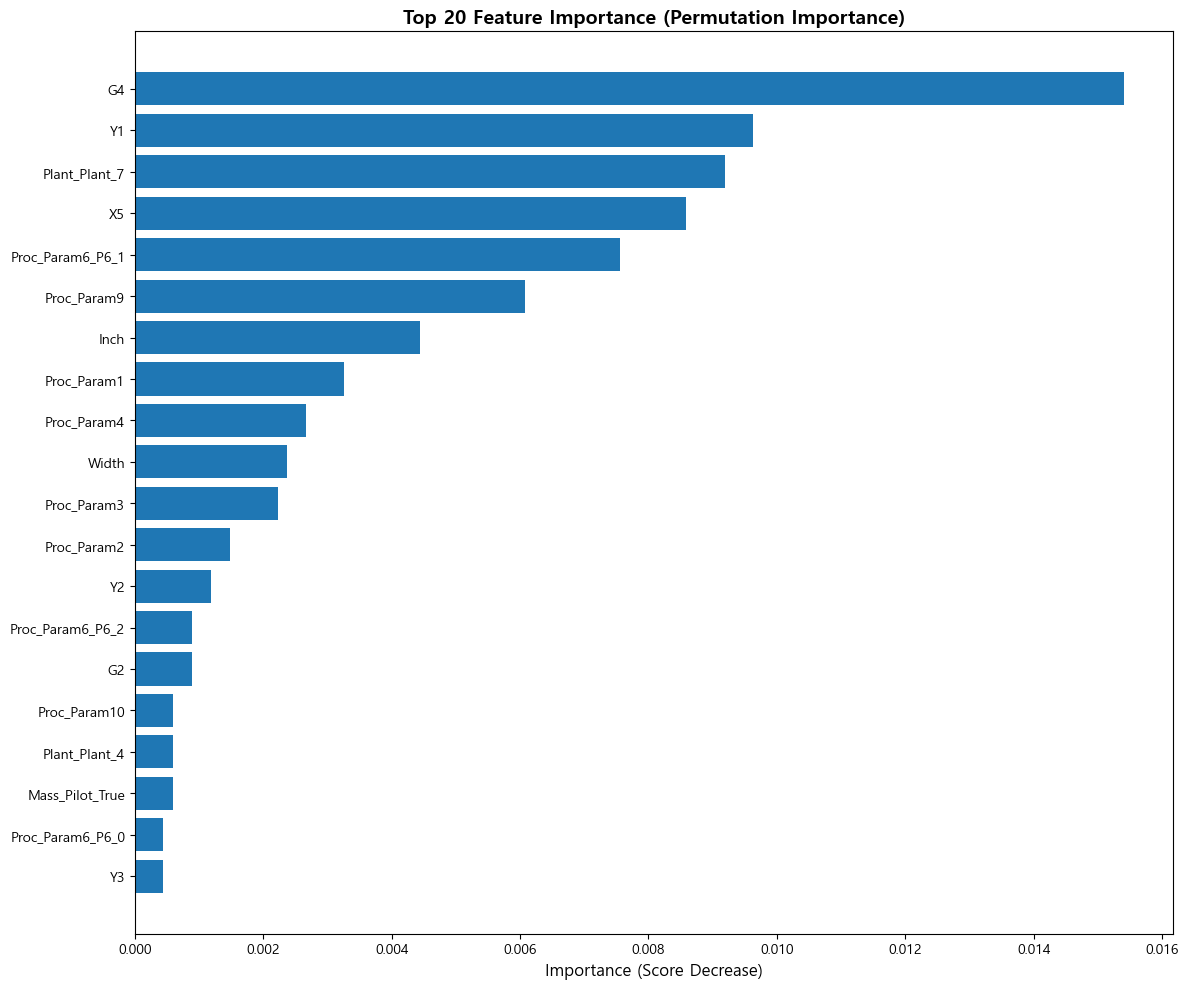

In [13]:
# 전처리된 feature 이름 생성
# OneHotEncoder가 생성한 feature 이름
ohe_feature_names = OE.get_feature_names_out(cat_list).tolist()
# 숫자형 feature 이름
numeric_feature_names = num_list
# 전체 feature 이름 (OneHotEncoder feature + 숫자형 feature)
all_feature_names = ohe_feature_names + numeric_feature_names

print(f"원본 feature 개수: {len(val_x.columns)}")
print(f"전처리된 feature 개수: {len(all_feature_names)}")
print(f"모델이 기대하는 feature 개수: {model.n_features_in_}")

# Permutation Importance 계산
perm = PermutationImportance(model, scoring='roc_auc', n_iter=10, random_state=22).fit(preprocess(val_x, cat_list, num_list), y_val_labels)

# eli5 HTML 출력
eli5.show_weights(perm, top=41, feature_names=all_feature_names)

# DataFrame으로 변환하여 더 자세히 보기
from eli5 import explain_weights_df
importance_df = explain_weights_df(perm, feature_names=all_feature_names)
importance_df = importance_df.sort_values('weight', ascending=False)

print("\n" + "="*80)
print("📊 Permutation Importance 상위 41개 Feature")
print("="*80)
display(importance_df.head(41))

# 시각화
plt.figure(figsize=(12, 10))
top_n = 20
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['weight'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance (Score Decrease)', fontsize=12)
plt.title(f'Top {top_n} Feature Importance (Permutation Importance)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

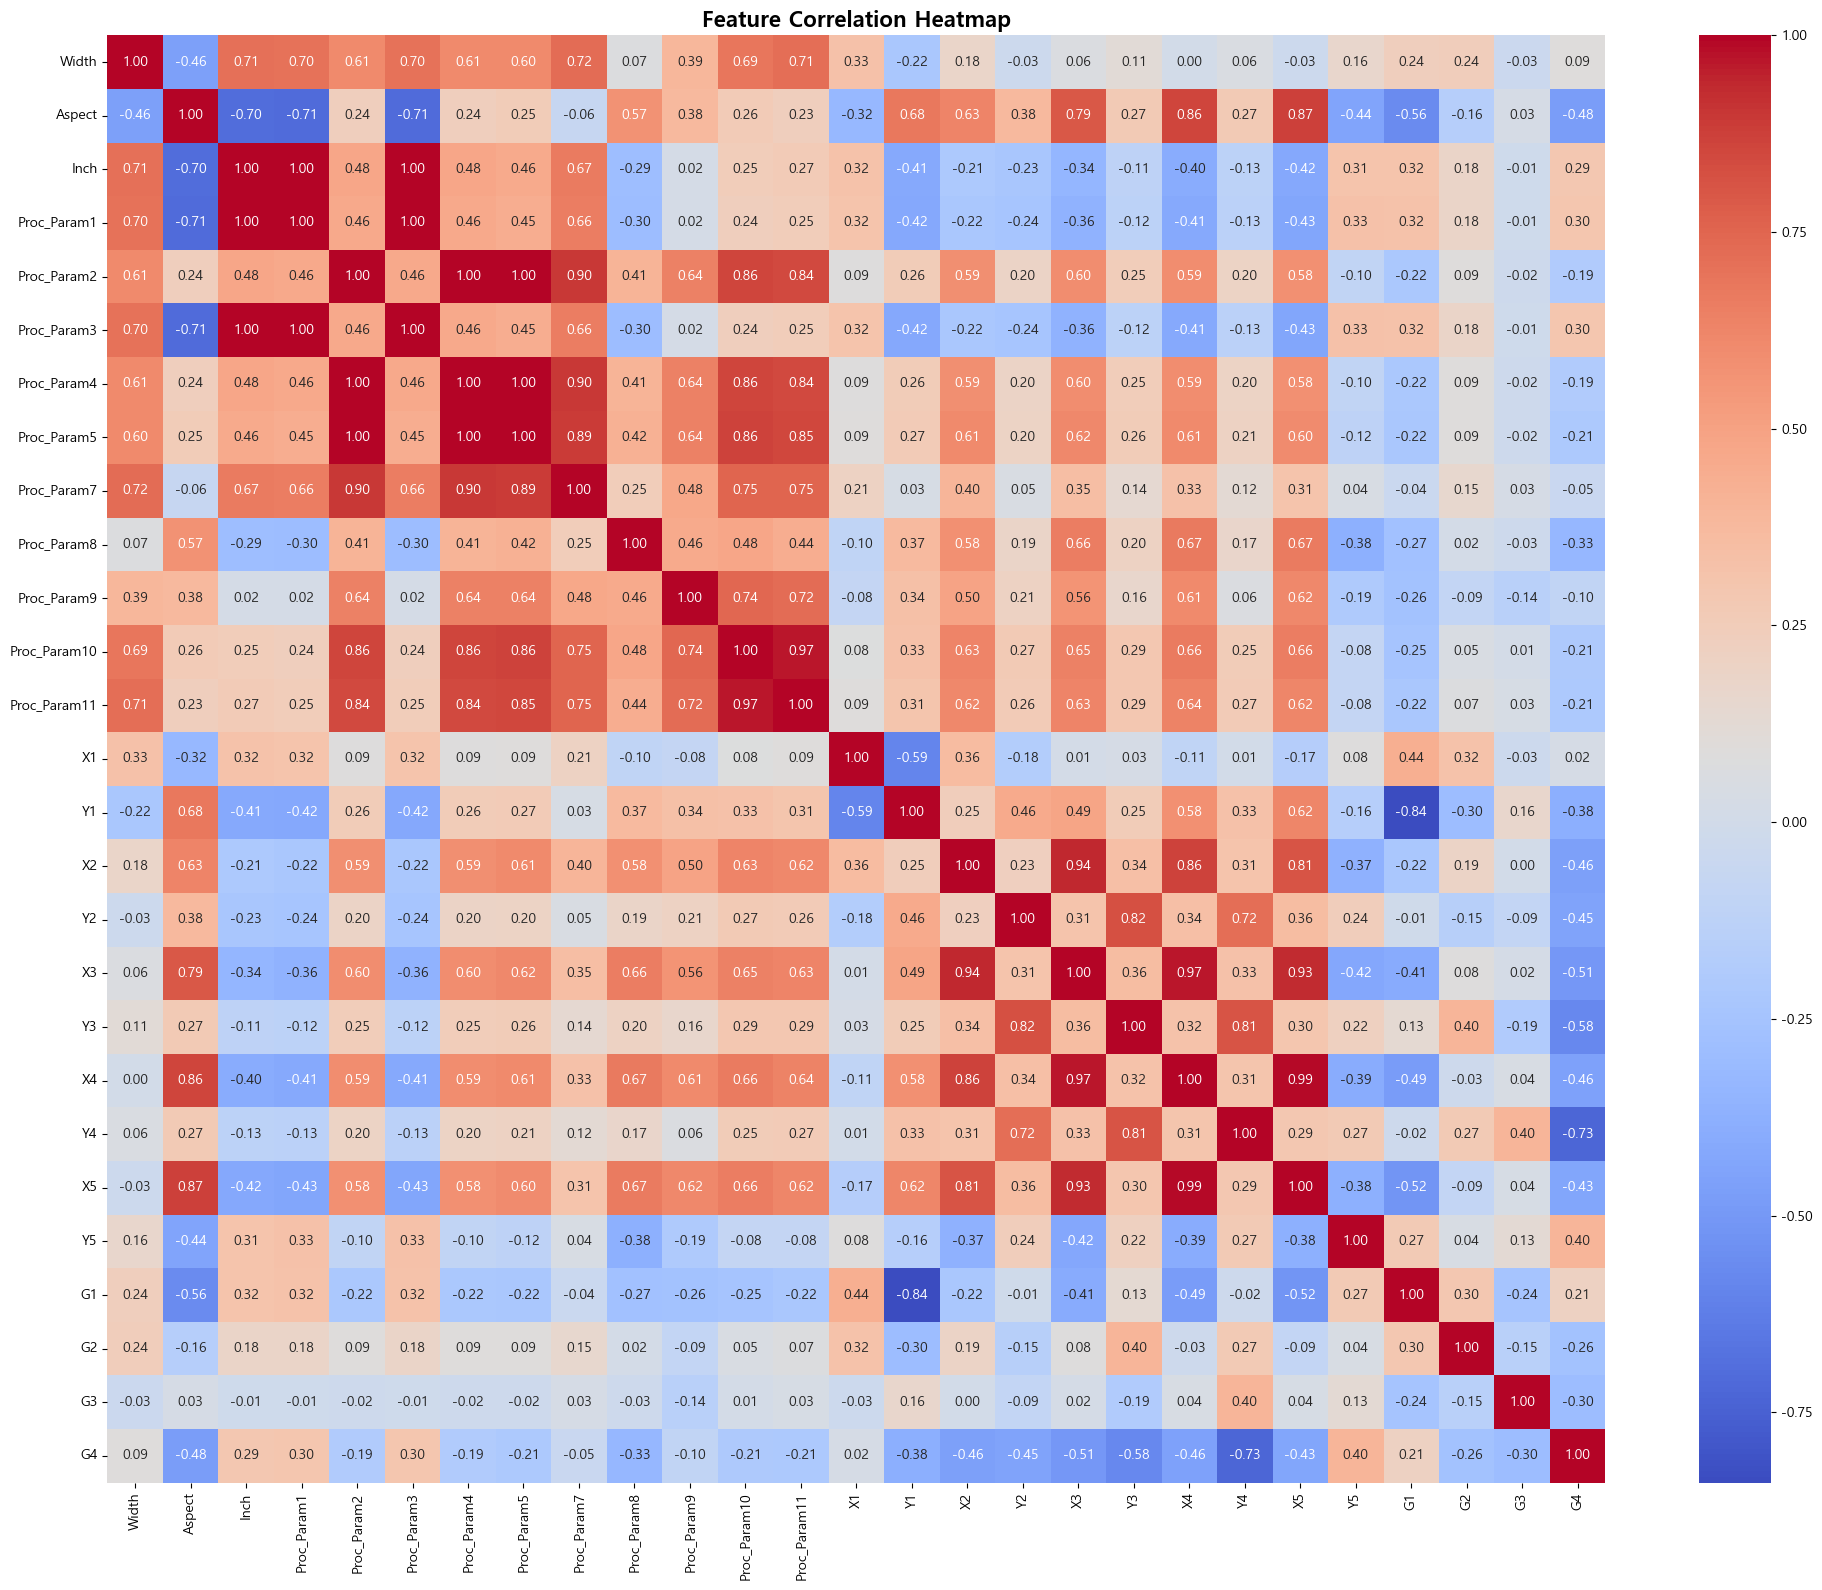

In [14]:
import seaborn as sns
corr_matrix = train_x.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

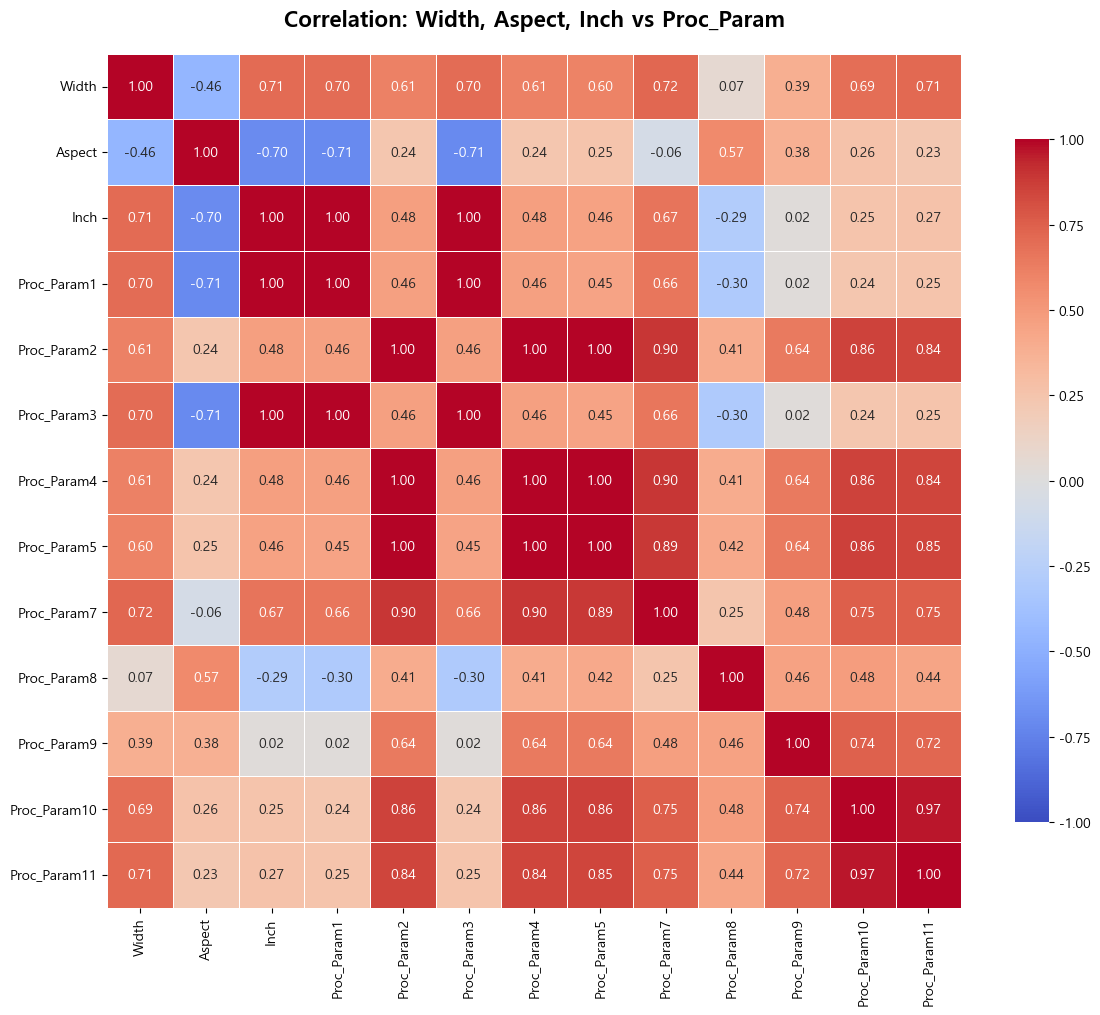


Group 1 컬럼: ['Width', 'Aspect', 'Inch', 'Proc_Param1', 'Proc_Param2', 'Proc_Param3', 'Proc_Param4', 'Proc_Param5', 'Proc_Param7', 'Proc_Param8', 'Proc_Param9', 'Proc_Param10', 'Proc_Param11']



In [15]:
import seaborn as sns

# 숫자형 컬럼만 선택
train_x_numeric = train_x.select_dtypes(include=[np.number])

# 1. Width, Aspect, Inch와 Proc_Param들의 상관계수 히트맵
cols_group1 = ['Width', 'Aspect', 'Inch'] + [col for col in train_x_numeric.columns if 'Proc_Param' in col]
corr_group1 = train_x_numeric[cols_group1].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_group1, annot=True, cmap='coolwarm', fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, center=0)
plt.title('Correlation: Width, Aspect, Inch vs Proc_Param', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"Group 1 컬럼: {cols_group1}")
print(f"{'='*80}\n")


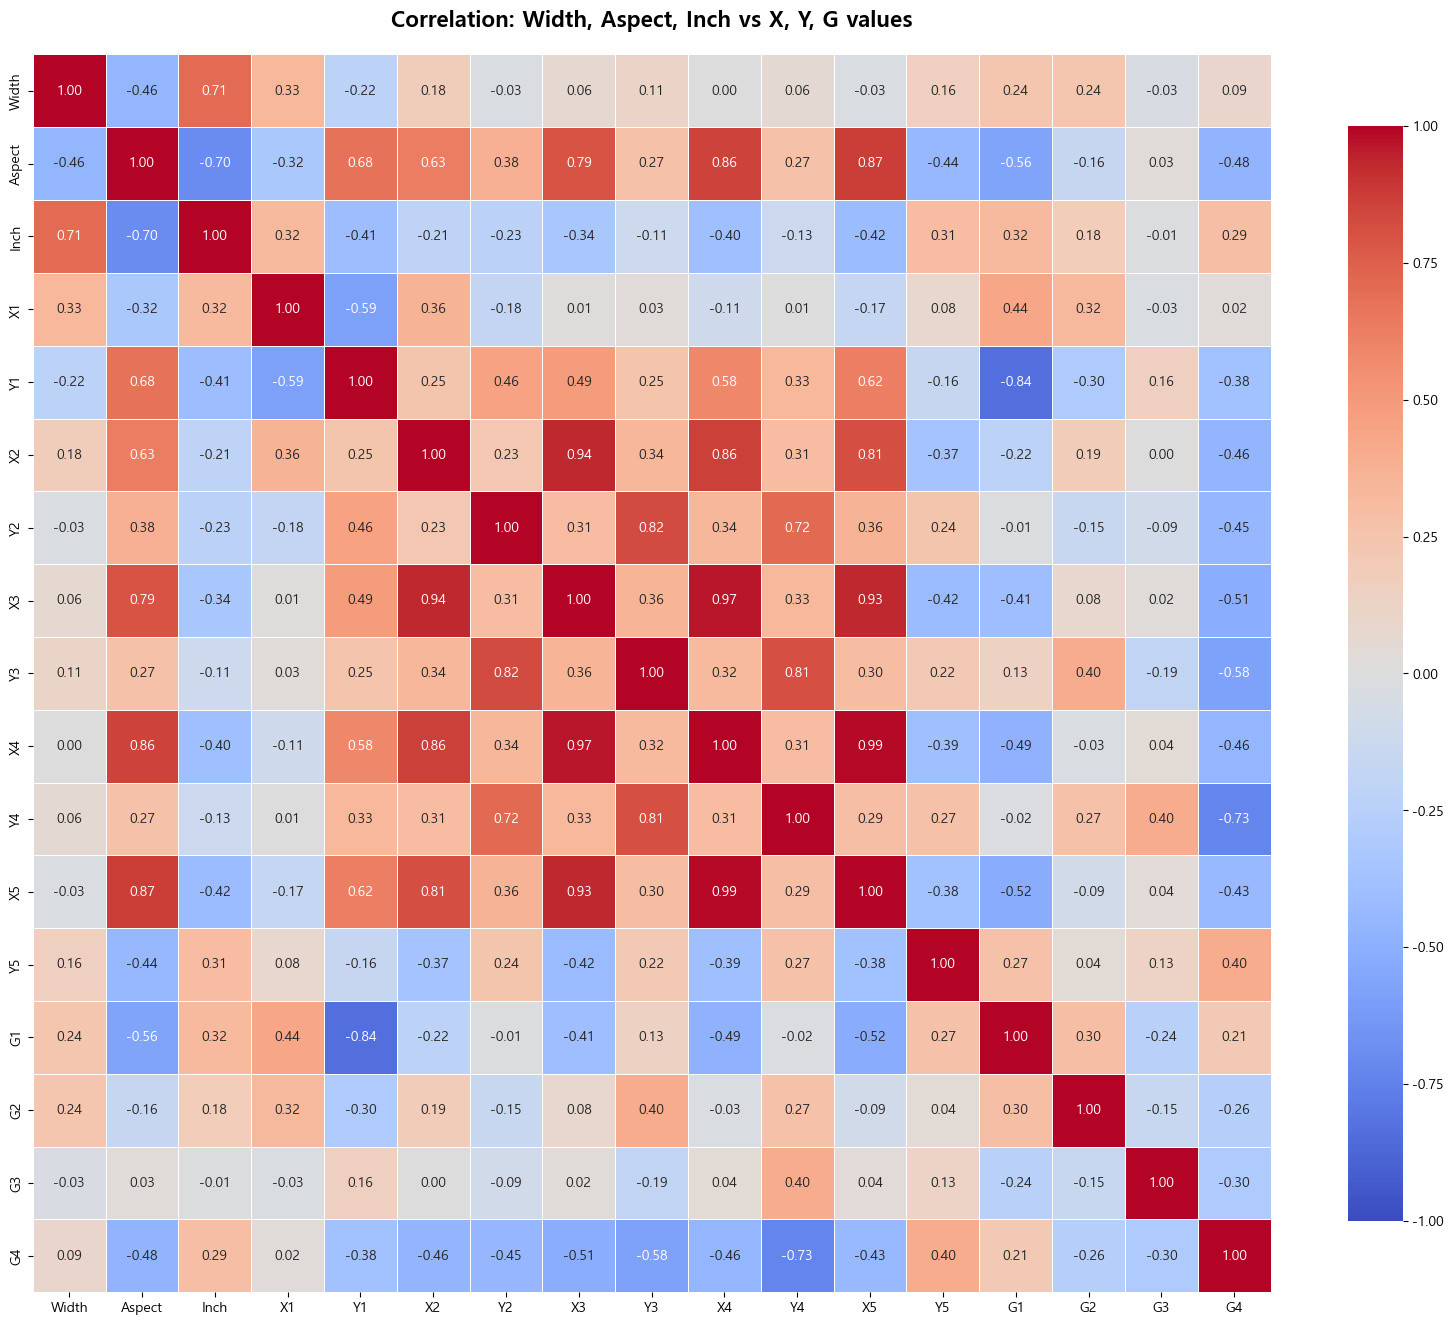


Group 2 컬럼 개수: 17개
X, Y, G 컬럼 예시: ['X1', 'Y1', 'X2', 'Y2', 'X3', 'Y3', 'X4', 'Y4', 'X5', 'Y5', 'G1', 'G2', 'G3', 'G4']



In [16]:
# 2. Width, Aspect, Inch와 X, Y, G 값들의 상관계수 히트맵
cols_group2 = ['Width', 'Aspect', 'Inch'] + [col for col in train_x_numeric.columns if col.startswith(('X', 'Y', 'G'))]
corr_group2 = train_x_numeric[cols_group2].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_group2, annot=True, cmap='coolwarm', fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, center=0)
plt.title('Correlation: Width, Aspect, Inch vs X, Y, G values', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"Group 2 컬럼 개수: {len(cols_group2)}개")
print(f"X, Y, G 컬럼 예시: {[col for col in cols_group2 if col.startswith(('X', 'Y', 'G'))][:15]}")
print(f"{'='*80}\n")


In [17]:
train_x

,Mass_Pilot,Width,Aspect,Inch,Plant,Proc_Param1,Proc_Param2,Proc_Param3,Proc_Param4,Proc_Param5,...,X3,Y3,X4,Y4,X5,Y5,G1,G2,G3,G4
0,False,245,40,19,Plant_6,465.00,631.85,1460.8,1985,2059,...,64.907,1.421,86.519,1.388,112.240,1.492,-0.023433,0.003384,-0.001527,0.004043
1,False,275,40,21,Plant_2,516.01,701.87,1621.1,2205,2291,...,79.686,1.687,98.663,1.591,121.010,1.362,0.022458,0.012190,-0.005059,-0.010247
2,False,225,45,17,Plant_7,416.99,583.14,1310.0,1832,1918,...,65.753,1.458,90.073,1.373,113.811,1.360,0.042622,-0.017465,-0.003495,-0.000548
3,True,275,30,20,Plant_7,490.01,623.89,1539.4,1960,2040,...,65.243,1.280,83.531,1.458,95.943,1.422,0.047047,0.034439,0.009733,-0.002900
4,True,265,45,21,Plant_2,516.01,714.61,1621.1,2245,2336,...,69.387,1.661,96.540,1.514,123.066,1.411,-0.007080,0.000190,-0.005414,-0.003883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,False,255,35,18,Plant_9,442.01,586.01,1388.6,1841,1921,...,59.046,1.231,78.684,1.264,102.414,1.444,-0.010434,-0.020248,0.001680,0.007585
716,True,265,70,17,Plant_9,416.99,745.48,1310.0,2342,2421,...,112.285,1.647,156.391,1.715,201.196,1.078,-0.003254,-0.000922,0.001542,-0.014217
717,False,265,70,17,Plant_9,416.99,745.48,1310.0,2342,2425,...,111.966,1.673,168.992,1.807,225.021,1.449,-0.005316,0.000839,0.002350,-0.006390
718,False,255,55,20,Plant_9,488.00,735.93,1533.1,2312,2392,...,90.078,1.527,124.630,1.562,158.667,1.392,-0.010182,0.000319,0.001013,-0.004995


Inch, Proc_Param1, Proc_Param3 에서 Inch 만 사용   
Proc_Param1, Proc_Param3 drop

In [18]:
train_x_ablation1 = train_x.drop(columns=['Proc_Param1', 'Proc_Param3'])
val_x_ablation1 = val_x.drop(columns=['Proc_Param1', 'Proc_Param3'])

cat_list_ablation1 = train_x_ablation1.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_ablation1 = sorted(list(set(train_x_ablation1.columns) - set(cat_list_ablation1)))

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_x_ablation1, cat_list_ablation1, num_list_ablation1), train_y)

pred = model.predict_proba(preprocess(val_x_ablation1, cat_list_ablation1, num_list_ablation1))[:,1]

total_score, roc_auc, total_net_profit, k = _calculate_competition_score(y_val_labels, pred)
print(f'AUC: {roc_auc:.4f}, Net Profit: {total_net_profit}, Score: {total_score:.4f}')


AUC: 0.8474, Net Profit: 1400, Score: 0.6974


Proc_Param2, Proc_Param4, Proc_Param5, Proc_param7, Proc_param10, Proc_param11    
Proc_param7 선택

In [21]:
train_x_ablation2 = train_x.drop(columns=['Proc_Param2', 'Proc_Param4', 'Proc_Param5', 'Proc_Param10', 'Proc_Param11'])
val_x_ablation2 = val_x.drop(columns=['Proc_Param2', 'Proc_Param4', 'Proc_Param5', 'Proc_Param10', 'Proc_Param11'])

cat_list_ablation2 = train_x_ablation2.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_ablation2 = sorted(list(set(train_x_ablation2.columns) - set(cat_list_ablation2)))

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_x_ablation2, cat_list_ablation2, num_list_ablation2), train_y)

pred = model.predict_proba(preprocess(val_x_ablation2, cat_list_ablation2, num_list_ablation2))[:,1]

total_score, roc_auc, total_net_profit, k = _calculate_competition_score(y_val_labels, pred)
print(f'AUC: {roc_auc:.4f}, Net Profit: {total_net_profit}, Score: {total_score:.4f}')

AUC: 0.8385, Net Profit: 1400, Score: 0.6884


X2, X3, X4, X5, (Aspect)   
X5 선택

In [25]:
train_x_ablation3 = train_x.drop(columns=['X2', 'X3', 'X4'])
val_x_ablation3 = val_x.drop(columns=['X2', 'X3', 'X4'])

cat_list_ablation3 = train_x_ablation3.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_ablation3 = sorted(list(set(train_x_ablation3.columns) - set(cat_list_ablation3)))

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_x_ablation3, cat_list_ablation3, num_list_ablation3), train_y)

pred = model.predict_proba(preprocess(val_x_ablation3, cat_list_ablation3, num_list_ablation3))[:,1]

total_score, roc_auc, total_net_profit, k = _calculate_competition_score(y_val_labels, pred)
print(f'AUC: {roc_auc:.4f}, Net Profit: {total_net_profit}, Score: {total_score:.4f}')

AUC: 0.8756, Net Profit: 1400, Score: 0.7251


In [24]:
train_x_ablation4 = train_x.drop(columns=['X2', 'X3', 'X4', 'Aspect'])
val_x_ablation4 = val_x.drop(columns=['X2', 'X3', 'X4', 'Aspect'])

cat_list_ablation4 = train_x_ablation4.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_ablation4 = sorted(list(set(train_x_ablation4.columns) - set(cat_list_ablation4)))

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_x_ablation4, cat_list_ablation4, num_list_ablation4), train_y)

pred = model.predict_proba(preprocess(val_x_ablation4, cat_list_ablation4, num_list_ablation4))[:,1]

total_score, roc_auc, total_net_profit, k = _calculate_competition_score(y_val_labels, pred)
print(f'AUC: {roc_auc:.4f}, Net Profit: {total_net_profit}, Score: {total_score:.4f}')

AUC: 0.8607, Net Profit: 1400, Score: 0.7107


Y2, Y3, Y4, G4   
G4 선택

In [27]:
train_x_ablation5 = train_x.drop(columns=['Y2', 'Y3', 'Y4'])
val_x_ablation5 = val_x.drop(columns=['Y2', 'Y3', 'Y4'])

cat_list_ablation5 = train_x_ablation5.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_ablation5 = sorted(list(set(train_x_ablation5.columns) - set(cat_list_ablation5)))

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_x_ablation5, cat_list_ablation5, num_list_ablation5), train_y)

pred = model.predict_proba(preprocess(val_x_ablation5, cat_list_ablation5, num_list_ablation5))[:,1]

total_score, roc_auc, total_net_profit, k = _calculate_competition_score(y_val_labels, pred)
print(f'AUC: {roc_auc:.4f}, Net Profit: {total_net_profit}, Score: {total_score:.4f}')

AUC: 0.8504, Net Profit: 1400, Score: 0.7004


Y1, G1   
Y1 선택

In [28]:
train_x_ablation6 = train_x.drop(columns=['G1'])
val_x_ablation6 = val_x.drop(columns=['G1'])

cat_list_ablation6 = train_x_ablation6.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_ablation6 = sorted(list(set(train_x_ablation6.columns) - set(cat_list_ablation6)))

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_x_ablation6, cat_list_ablation6, num_list_ablation6), train_y)

pred = model.predict_proba(preprocess(val_x_ablation6, cat_list_ablation6, num_list_ablation6))[:,1]

total_score, roc_auc, total_net_profit, k = _calculate_competition_score(y_val_labels, pred)
print(f'AUC: {roc_auc:.4f}, Net Profit: {total_net_profit}, Score: {total_score:.4f}')

AUC: 0.8681, Net Profit: 1400, Score: 0.7179


X2, X3, X4, X5, (Aspect) → X5   
(Y1, G1) → Y1

In [48]:
train_x_ablation7 = train_x.drop(columns=['X2', 'X3', 'X4', 'Aspect', 'G1'])
val_x_ablation7 = val_x.drop(columns=['X2', 'X3', 'X4', 'Aspect', 'G1'])

cat_list_ablation7 = train_x_ablation7.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_ablation7 = sorted(list(set(train_x_ablation7.columns) - set(cat_list_ablation7)))

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_x_ablation7, cat_list_ablation7, num_list_ablation7), train_y)

pred = model.predict_proba(preprocess(val_x_ablation7, cat_list_ablation7, num_list_ablation7))[:,1]

total_score, roc_auc, total_net_profit, k = _calculate_competition_score(y_val_labels, pred)
print(f'AUC: {roc_auc:.4f}, Net Profit: {total_net_profit}, Score: {total_score:.4f}')


AUC: 0.8785, Net Profit: 2000, Score: 0.8701


# Apply to test.csv

In [115]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

train_X = train.drop(columns=['Class']).iloc[:,:-256*3]
train_Y = train['Class'].apply(lambda x:1 if x=='NG' else 0)
test_X = test.drop(columns=['ID']).iloc[:,:-256*3]

cat_list = train_X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list = sorted(list(set(train_X.columns) - set(cat_list)))

OE = OneHotEncoder(min_frequency=0.01,handle_unknown='infrequent_if_exist',sparse_output=False)
OE.fit(train_X[cat_list])

def preprocess(dataset, category_list, numeric_list):
    Xc = OE.transform(dataset[category_list])
    Xn = np.array(dataset[numeric_list])
    return np.concatenate([Xc, Xn], axis=1)

train_X = train_X.drop(columns=['X2', 'X3', 'X4', 'Aspect', 'G1'])
test_X = test_X.drop(columns=['X2', 'X3', 'X4', 'Aspect', 'G1'])

cat_list_ablation = train_X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_ablation = sorted(list(set(train_X.columns) - set(cat_list_ablation)))

model = RandomForestClassifier(n_estimators=1000, max_depth=5)
model.fit(preprocess(train_X, cat_list_ablation, num_list_ablation), train_Y)

pred = model.predict_proba(preprocess(test_X, cat_list_ablation, num_list_ablation))[:,1]

submission = pd.read_csv("sample_submission.csv")
submission['probability'] = np.concatenate([pred,pred])

decision_id_L_list = submission.iloc[:466].sort_values('probability').iloc[:200]['ID']
decision_id_P_list = submission.iloc[466:].sort_values('probability').iloc[:200]['ID']

submission.loc[submission['ID'].isin(decision_id_L_list), 'decision'] = True
submission.loc[submission['ID'].isin(decision_id_P_list), 'decision'] = True


submission.to_csv("first_ablation_submission.csv", index=False)
display(submission)

,ID,probability,decision
0,ID_0_L,0.520805,False
1,ID_1_L,0.071953,True
2,ID_2_L,0.072754,True
3,ID_3_L,0.067662,True
4,ID_4_L,0.355669,False
...,...,...,...
927,ID_461_P,0.071102,True
928,ID_462_P,0.074259,True
929,ID_463_P,0.107516,False
930,ID_464_P,0.565935,False


# CNN Feature 추출기 사용

In [3]:
# ============================================================
# CNN 모델 정의 및 학습
# ============================================================

# 1. 공간 래스터화 클래스
class SpatialRasterizer:
    def __init__(self, x_min, x_max, y_min, y_max, grid_size=64):
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max
        self.grid_size = grid_size
        self.x_range = x_max - x_min if x_max > x_min else 1
        self.y_range = y_max - y_min if y_max > y_min else 1
        
    def rasterize_with_real_coordinates(self, data_row):
        x_cols = [f'x{i}' for i in range(256)]
        y_cols = [f'y{i}' for i in range(256)]
        p_cols = [f'p{i}' for i in range(256)]
        
        x_coords = data_row[x_cols].values
        y_coords = data_row[y_cols].values
        p_values = data_row[p_cols].values
        
        grid = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        count_grid = np.zeros((self.grid_size, self.grid_size), dtype=np.int8)

        for i in range(256):
            if not (np.isnan(x_coords[i]) or np.isnan(y_coords[i]) or np.isnan(p_values[i])):
                x_norm = (x_coords[i] - self.x_min) / self.x_range
                y_norm = (y_coords[i] - self.y_min) / self.y_range
                x_idx = int(np.clip(x_norm * (self.grid_size - 1), 0, self.grid_size - 1))
                y_idx = int(np.clip(y_norm * (self.grid_size - 1), 0, self.grid_size - 1))
                grid[y_idx, x_idx] += p_values[i]
                count_grid[y_idx, x_idx] += 1
        
        mask = count_grid > 0
        grid[mask] = grid[mask] / count_grid[mask]
        
        return grid


In [4]:
# 2. ImageCNN 모델 정의
class ImageCNN(nn.Module):
    def __init__(self, output_dim=64, input_size=64):
        super(ImageCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) 
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        
        self.batch_norm1 = nn.BatchNorm2d(32)
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.batch_norm3 = nn.BatchNorm2d(128)
        self.batch_norm4 = nn.BatchNorm2d(256)
        
        final_size = input_size // 16
        self.fc1 = nn.Linear(256 * final_size * final_size, 512)
        self.fc_out = nn.Linear(512, output_dim) 
        
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.batch_norm1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.batch_norm2(self.conv2(x))), 2)
        x = F.max_pool2d(F.relu(self.batch_norm3(self.conv3(x))), 2)
        x = F.max_pool2d(F.relu(self.batch_norm4(self.conv4(x))), 2)
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc_out(x)


In [5]:
# 3. FullE2EModel 정의 (이미지 CNN + 기본 feature MLP)
class FullE2EModel(nn.Module):
    def __init__(self, basic_feature_dim, image_cnn_output_dim=64, basic_mlp_output_dim=32, input_grid_size=64):
        super(FullE2EModel, self).__init__()
        
        self.image_cnn = ImageCNN(output_dim=image_cnn_output_dim, input_size=input_grid_size)
        
        self.basic_mlp = nn.Sequential(
            nn.Linear(basic_feature_dim, basic_feature_dim * 2),
            nn.ReLU(),
            nn.BatchNorm1d(basic_feature_dim * 2),
            nn.Dropout(0.3),
            nn.Linear(basic_feature_dim * 2, basic_mlp_output_dim),
            nn.ReLU()
        )
        
        combined_dim = image_cnn_output_dim + basic_mlp_output_dim
        self.head = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 1) 
        )
    
    def forward(self, x_image, x_basic):
        img_feat = self.image_cnn(x_image)
        basic_feat = self.basic_mlp(x_basic)
        combined = torch.cat((img_feat, basic_feat), dim=1)
        output = self.head(combined) # 96차원 -> 1차원
        return output

    # 피처 추출을 위한 '머리 없는' forward
    def extract_features(self, x_image, x_basic):
        img_feat = self.image_cnn(x_image)
        basic_feat = self.basic_mlp(x_basic)
        combined = torch.cat((img_feat, basic_feat), dim=1)
        return combined # 96차원 피처 반환


In [6]:
# 4. 데이터셋 클래스
class MultiModalDataset(Dataset):
    def __init__(self, full_df, basic_features_np, rasterizer, labels_np=None):
        self.full_df = full_df.reset_index(drop=True)
        self.basic_features_np = basic_features_np
        self.rasterizer = rasterizer
        self.labels_np = labels_np
        self.is_test = (labels_np is None)

    def __len__(self):
        return len(self.full_df)

    def __getitem__(self, idx):
        data_row = self.full_df.iloc[idx]
        image_grid = self.rasterizer.rasterize_with_real_coordinates(data_row)
        image_tensor = torch.from_numpy(image_grid).unsqueeze(0) # (1, 64, 64)
        basic_feat_tensor = torch.from_numpy(self.basic_features_np[idx])
        
        if self.is_test:
            return image_tensor, basic_feat_tensor
        else:
            label_tensor = torch.tensor(self.labels_np[idx], dtype=torch.float32).view(1)
            return image_tensor, basic_feat_tensor, label_tensor


In [7]:
# 5. CNN 모델 학습 함수
def train_cnn_model(train_loader, basic_feature_dim, n_epochs=50, device=None):
    """CNN 모델 학습"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🔧 사용 디바이스: {device}")
    
    model = FullE2EModel(basic_feature_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss() 
    
    print("\n🧠 CNN 피처 추출기 학습 시작...")
    
    for epoch in range(n_epochs):
        model.train()
        train_loss_total = 0.0
        
        for img, basic, labels in train_loader:
            img, basic, labels = img.to(device), basic.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(img, basic)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item()
        
        avg_train_loss = train_loss_total / len(train_loader)
        print(f"  Epoch [{epoch+1}/{n_epochs}], Train Loss: {avg_train_loss:.4f}")
    
    print("✅ CNN 피처 추출기 학습 완료.")
    return model


In [8]:
# 6. CNN Feature 추출 함수
def extract_cnn_features(model, loader, device=None):
    """학습된 모델로부터 CNN feature 추출"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    all_features = []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:  # train 데이터 (img, basic, labels)
                img, basic, _ = batch
            else:  # test 데이터 (img, basic)
                img, basic = batch
            img, basic = img.to(device), basic.to(device)
            features_batch = model.extract_features(img, basic)
            all_features.append(features_batch.cpu().numpy())
    
    return np.concatenate(all_features, axis=0)


In [9]:
# ============================================================
# CNN 모델 학습 실행
# ============================================================

# 1. 전체 train 데이터 로드 (좌표 데이터 포함)
train_full = pd.read_csv("train.csv")
train_X_basic = train_full.drop(columns=['Class']).iloc[:,:-256*3]
train_Y = train_full['Class'].apply(lambda x: 1 if x == 'NG' else 0)

# 2. Feature ablation 적용 (최적 조합)
train_X_basic = train_X_basic.drop(columns=['X2', 'X3', 'X4', 'Aspect', 'G1'])

# 3. 기본 feature 전처리
cat_list_cnn = train_X_basic.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_list_cnn = sorted(list(set(train_X_basic.columns) - set(cat_list_cnn)))

OE_cnn = OneHotEncoder(min_frequency=0.01, handle_unknown='infrequent_if_exist', sparse_output=False)
OE_cnn.fit(train_X_basic[cat_list_cnn])

Scaler_cnn = StandardScaler()
Scaler_cnn.fit(train_X_basic[num_list_cnn])

def preprocess_cnn(dataset):
    Xc = OE_cnn.transform(dataset[cat_list_cnn])
    Xn = Scaler_cnn.transform(dataset[num_list_cnn])
    return np.concatenate([Xc, Xn], axis=1).astype(np.float32)

X_train_basic_np = preprocess_cnn(train_X_basic)
basic_feature_dim = X_train_basic_np.shape[1]
print(f"기본 feature 차원: {basic_feature_dim}")

# 4. 좌표 범위 분석 및 래스터화 설정
x_cols = [f'x{i}' for i in range(256)]
y_cols = [f'y{i}' for i in range(256)]
x_values = train_full[x_cols].values.flatten()
y_values = train_full[y_cols].values.flatten()
x_values = x_values[~np.isnan(x_values)]
y_values = y_values[~np.isnan(y_values)]

x_min, x_max = x_values.min(), x_values.max()
y_min, y_max = y_values.min(), y_values.max()

print(f"📊 좌표 범위: X({x_min:.2f} ~ {x_max:.2f}), Y({y_min:.2f} ~ {y_max:.2f})")

rasterizer = SpatialRasterizer(x_min, x_max, y_min, y_max, grid_size=64)

# 5. 데이터셋 및 로더 생성
train_dataset = MultiModalDataset(train_full, X_train_basic_np, rasterizer, train_Y.values)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 6. CNN 모델 학습
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn_model = train_cnn_model(train_loader, basic_feature_dim, n_epochs=13, device=device)

# 7. 모델 저장
torch.save(cnn_model.state_dict(), 'cnn_model.pth')
print("✅ 모델 저장 완료: cnn_model.pth")


기본 feature 차원: 36
📊 좌표 범위: X(160.58 ~ 423.77), Y(47.34 ~ 185.62)
🔧 사용 디바이스: cpu

🧠 CNN 피처 추출기 학습 시작...
  Epoch [1/13], Train Loss: 0.7018
  Epoch [2/13], Train Loss: 0.6518
  Epoch [3/13], Train Loss: 0.5939
  Epoch [4/13], Train Loss: 0.5511
  Epoch [5/13], Train Loss: 0.5133
  Epoch [6/13], Train Loss: 0.4700
  Epoch [7/13], Train Loss: 0.4381
  Epoch [8/13], Train Loss: 0.4051
  Epoch [9/13], Train Loss: 0.3861
  Epoch [10/13], Train Loss: 0.3562
  Epoch [11/13], Train Loss: 0.3444
  Epoch [12/13], Train Loss: 0.3162
  Epoch [13/13], Train Loss: 0.3293
✅ CNN 피처 추출기 학습 완료.
✅ 모델 저장 완료: cnn_model.pth


In [10]:
# ============================================================
# CNN Feature 추출 및 하이브리드 모델 학습
# ============================================================

# 1. Train 데이터에서 CNN feature 추출
train_loader_seq = DataLoader(train_dataset, batch_size=32, shuffle=False)
X_train_cnn_feats = extract_cnn_features(cnn_model, train_loader_seq, device=device)
print(f"추출된 CNN feature 형태 (Train): {X_train_cnn_feats.shape}")

# 2. 하이브리드 feature 생성 (기본 feature + CNN feature)
X_train_hybrid = np.concatenate([X_train_basic_np, X_train_cnn_feats], axis=1)
print(f"하이브리드 feature 형태 (Train): {X_train_hybrid.shape}")

# 3. RandomForest 모델 학습 (하이브리드 feature 사용)
rf_model_hybrid = RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1)
rf_model_hybrid.fit(X_train_hybrid, train_Y)
print("✅ 하이브리드 RandomForest 모델 학습 완료.")



추출된 CNN feature 형태 (Train): (720, 96)
하이브리드 feature 형태 (Train): (720, 132)
✅ 하이브리드 RandomForest 모델 학습 완료.


In [11]:
# ============================================================
# Test.csv 예측 및 제출 파일 생성
# ============================================================

# 1. Test 데이터 로드
print("📁 Test 데이터 로드 중...")
test_df = pd.read_csv("test.csv")
test_X_basic = test_df.drop(columns=['ID']).iloc[:,:-256*3]

# 2. Feature ablation 적용 (Train과 동일하게)
test_X_basic = test_X_basic.drop(columns=['X2', 'X3', 'X4', 'Aspect', 'G1'])
print(f"Test 기본 feature 형태: {test_X_basic.shape}")

# 3. Test 기본 feature 전처리
X_test_basic_np = preprocess_cnn(test_X_basic)
print(f"전처리된 Test 기본 feature 형태: {X_test_basic_np.shape}")

# 4. Test CNN feature 추출
print("\n✨ Test CNN feature 추출 중...")
test_dataset = MultiModalDataset(test_df, X_test_basic_np, rasterizer, labels_np=None)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
X_test_cnn_feats = extract_cnn_features(cnn_model, test_loader, device=device)
print(f"추출된 Test CNN feature 형태: {X_test_cnn_feats.shape}")

# 5. Test 하이브리드 feature 생성
X_test_hybrid = np.concatenate([X_test_basic_np, X_test_cnn_feats], axis=1)
print(f"Test 하이브리드 feature 형태: {X_test_hybrid.shape}")

# 6. Test 데이터 예측
print("\n🔮 Test 데이터 예측 중...")
test_pred = rf_model_hybrid.predict_proba(X_test_hybrid)[:, 1]
print(f"예측 완료: {len(test_pred)}개 샘플")
print(f"불량률 범위: {test_pred.min():.4f} ~ {test_pred.max():.4f}")
print(f"평균 불량률: {test_pred.mean():.4f}")


📁 Test 데이터 로드 중...
Test 기본 feature 형태: (466, 25)
전처리된 Test 기본 feature 형태: (466, 36)

✨ Test CNN feature 추출 중...
추출된 Test CNN feature 형태: (466, 96)
Test 하이브리드 feature 형태: (466, 132)

🔮 Test 데이터 예측 중...
예측 완료: 466개 샘플
불량률 범위: 0.0000 ~ 1.0000
평균 불량률: 0.1533


In [12]:
submission = pd.read_csv("sample_submission.csv")
submission['probability'] = np.concatenate([test_pred,test_pred])

decision_id_L_list = submission.iloc[:466].sort_values('probability').iloc[:200]['ID']
decision_id_P_list = submission.iloc[466:].sort_values('probability').iloc[:200]['ID']

submission.loc[submission['ID'].isin(decision_id_L_list), 'decision'] = True
submission.loc[submission['ID'].isin(decision_id_P_list), 'decision'] = True


submission.to_csv("first_ablation_cnn_submission.csv", index=False)
display(submission)



,ID,probability,decision
0,ID_0_L,0.925,False
1,ID_1_L,0.015,True
2,ID_2_L,0.045,True
3,ID_3_L,0.045,True
4,ID_4_L,0.665,False
...,...,...,...
927,ID_461_P,0.000,True
928,ID_462_P,0.010,True
929,ID_463_P,0.050,False
930,ID_464_P,0.935,False
